### LANNELONGUE Vincent – GATIN Juliette

# Projet numérique : choix du pas de temps 

## Pas fixe

***Imports préalables :***

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import time

 ***Euler explicit pour un pas de temps fixe, dt :***

Schéma d'Euler explicit : $x^{j+1} = x^j + dt * f(t_{j}, x^j)$

In [5]:
def solve_euler_explicit(f, dt, tf, x0, t0 = 0): 
    t, x = [t0], [x0]
    while t[-1] < tf :
        x.append(x[-1] + dt * f(t[-1], x[-1]))
        t.append(t[-1] + dt)
    return t, x

***Une équation différentielle à tester :***

On considère $\dot{x} = x$ avec ($t_{0} = 0, x_{0}$ = 1) dont la solution est $x \mapsto exp(x)$

In [6]:
def f(t, x):
    return x

Affichage :

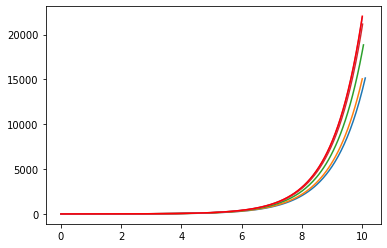

In [7]:
t0, x0 = 0, 1
tf = 10
Dt = [0.1, 0.08, 0.04, 0.01, 0.001]

for dt in Dt:
    t, x = solve_euler_explicit(f, dt, tf, x0 , t0)
    plt.plot(t, x)
sol = [np.exp(temps) for temps in t]
plt.plot(t, sol, color = 'red') #tracé théorique    
plt.show()

On observe que plus le pas de temps $dt$ diminue, plus on se rapproche de la courbe théorique (en ${\color{red}{rouge}}$).

### Mise en évidence de la convergence du schéma à l'ordre 1

**Calcul de l'erreur :** on considère $max\parallel x^j - x(t_{j}) \parallel$

In [8]:
def ecart_max(u, f, f_sol, dt, tf, x0, t0 = 0):
    t, x = u(f, dt, tf, x0, t0 = 0)
    e = []
    for i, temp in enumerate(t):
        e.append(abs(x[i] - f_sol(temp)))
    return max(e)

Générons une liste $pas$, contenant différents pas de temps.
Puis, traçons l'évolution de l'erreur maximale $e$ en fonction du pas de temps $dt$ : 

Pour notre exemple, on a : 

In [9]:
pas = np.arange(0.01, 0.1, 0.001)
f_sol = np.exp

e_11 = []
for dt in pas:
    e_11.append(ecart_max(solve_euler_explicit, f, f_sol, dt, 10, 1))

Vérifions la convergence du schéma à l'ordre 1 : visuellement, on s'attend à ce que l'évolution de l'erreur maximale $e$ soit proportionnelle à l'évolution du pas de temps $dt$

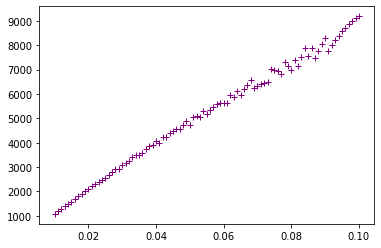

In [10]:
plt.plot(pas, e_11, '+', color = 'purple')
plt.show()

**Remarque :** la convergence à l'ordre 1 est bien vérifiée pour des pas de temps faibles mais plus celui-ci augmente, plus on s'écarte de la linéarité attendue. On voit donc bien qu'il y a stabilisation plus le pas $dt$ est petit.

***Heun explicit pour un pas de temps fixe, dt :***

Schéma de Heun explicit – $x^{j+1} = x^j + \frac{dt}{2} * (f(t_{j}, x^j) + f(t_{j+1}, x^j + dt * f(t_{j}, x^j))$

In [11]:
def solve_heun_explicit(f, dt, tf, x0, t0 = 0):
    t, x = [t0, t0 + dt], [x0]
    i = 0
    while t[-1] < tf:
        x.append(x[-1] + dt/2 * (f(t[i], x[-1]) + f(t[i+1], x[-1] + dt * f(t[i], x[-1]))))
        t.append(t[-1] + dt)
        i += 1
    return t[:-1], x

Affichage pour l'exemple 1:

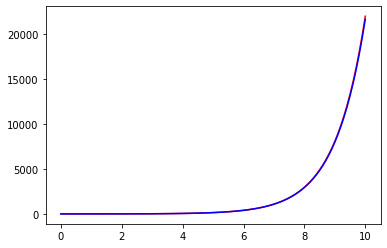

In [16]:
t0, x0 = 0, 1
tf = 10
dt = 0.1

t, x = solve_heun_explicit(f, dt, tf, x0 , t0)
sol = [np.exp(temps) for temps in t]

plt.plot(t, sol, color = 'red') #tracé théorique
plt.plot(t, x, color = 'blue')

plt.show()

Comparons les deux méthodes avec en ${\color{red}{rouge}}$, le tracé théorique; en ${\color{green}{vert}}$, le tracé du schéma d'ordre 1 (Euler explicit) et en ${\color{blue}{bleu}}$, le tracé du schéma d'ordre 2:

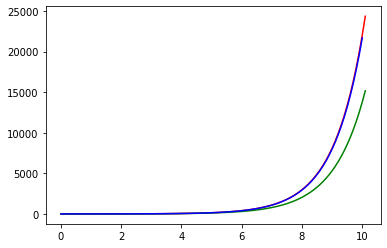

In [14]:
t0, x0 = 0, 1
tf = 10
dt = 0.1

t_1, x_1 = solve_euler_explicit(f, dt, tf, x0, t0)
t_2, x_2 = solve_heun_explicit(f, dt, tf, x0 , t0)
sol = [np.exp(temps) for temps in t_1]

plt.plot(t_1, sol, color = 'red') #tracé théorique
plt.plot(t_1, x_1, color = 'green')
plt.plot(t_2, x_2, color = 'blue')

plt.show()

**Remarques :** le tracé du schéma d'ordre 2 (${\color{blue}{bleu}}$) est effectivement bien plus précis que celui d'ordre 1 (${\color{green}{vert}}$) pour un même pas de temps $dt$. 

### Mise en évidence de la convergence du schéma à l'ordre 2

Vérifions la convergence du schéma à l'ordre 2 : visuellement, on s'attend à ce que l'évolution de l'erreur maximale $e$ soit quadratique par rapport à l'évolution du pas de temps $dt$

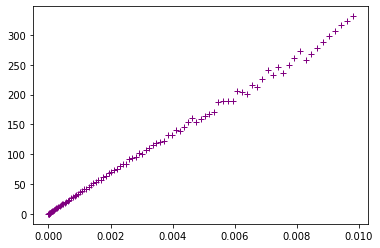

In [18]:
f_sol = np.exp
pas = np.arange(0.001, 0.1, 0.001)

e_2 = []
for dt in pas:
    e_2.append(ecart_max(solve_heun_explicit, f, f_sol, dt, 10, 1))


plt.plot(pas**2, e_2, '+', color = 'purple')
plt.show()

**Observation :** la convergence à l'ordre 2 semble être vérifiée. En effet, on observe bien une évolution quadratique de l'erreur en le pas de temps : le tracé de $e = f(dt^2)$ est bien linéaire.

## Adaptation du pas de temps

Supposons $f$ $C^1$, montrons que pour un schéma d'Euler explicit, on a :

$$\left\|e^{j+1}\right\|=\Delta t_{j} \frac{\left\|f\left(t_{j+1}, x^{j+1}\right)-f\left(t_{j}, x^{j}\right)\right\|}{2}+o\left(\Delta t_{j}^{2}\right)$$

De fait, on pourra estimer à chaque itération l'erreur commise $e^{j+1}$ et adpater le pas selon si celle-ci est inférieure ou supérieure au seuil de tolérance. 

***Démonstration :***

D'une part, on a par définition de l'erreur locale dûe à l'approximation de l'intégrale : $$ e^{j+1} = \tilde{x}(t_{j+1}) -x^{j+1} = \left(x^j + \int_{t_j}^{t_{j+1}} f(s,\tilde{x}(s))ds\right) $$ 

avec ${\tilde {x}}$ solution de $\dot{x}=f(x)$ et ${\tilde {x}}(t_{j})=x^j$.

De plus, le schéma d'Euler explicit donne: $x^{j+1} = x^j + \Delta t_j  f(t_j,x^j) $ . 

Or, $$\int_{t_j}^{t_{j+1}} f(s,\tilde{x}(s))ds = \frac{f(t_{j+1},\tilde{x}(t_{j+1})) - f(t_{j},\tilde{x}(t_{j}))}{2} \Delta t_{j} + o(\Delta t_j^2) \ \ (1)$$

Remplaçons $\tilde{x}(t_{j})$ par $x^j$ et $\tilde{x}(t_{j+1})$ par $x^{j+1}$:

Par définition, on a : $\tilde{x}(t_{j}) = x^{j}$ 

Et, en effectuant un développement de Taylor à l'ordre 2 car $f$ est $C^1$ donc $\tilde{x}$ est $C^2$, on a:

$$ \tilde{x}(t_{j+1}) = \tilde{x}(t_{j})+\Delta t_{j} \tilde{\dot{x}}(t_{j}) + \frac{\Delta(t_{j})^2}{2}\tilde{\ddot{x}}(t_{j}) + o(\Delta t_{j}^{2})$$

$$ \tilde{x}(t_{j+1}) = x^j +\Delta t_{j} f(t_{j}, x^{j})+ O(\Delta t_{j}^{2})$$

Soit, comme on utilise Euler explicit : $ \tilde{x}(t_{j+1})) = x^{j+1} + O(\Delta t_j^2)$

Ainsi, $ \tilde{x}(t_{j+1})) - x^{j+1} = O(\Delta t_j^2)$

Et, $ f(t_{j+1}, \tilde{x}(t_{j+1})) = f(t_{j+1}, x^{j+1})+\partial_{x}f(t_{j+1}, x^{j+1})(\tilde{x}(t_{j+1})-x^{j+1})+ o(\tilde{x}(t_{j+1})-x^{j+1})$


ie $ f(t_{j+1}, \tilde{x}(t_{j+1}))= f(t_{j+1}, x^{j+1})+O(\Delta t_{j}^{2})$ $(2)$

D'où, en utilisant $(1)$ et en injectant dans la définition de $e_{j+1}$, on a le résultat voulu : 

$$ e_{j+1}= \frac{f(t_{j+1},\tilde{x}(t_{j+1})) - f(t_{j},\tilde{x}(t_{j}))}{2} \Delta t_{j} + o(\Delta t_j^2)$$

Montrons de plus que $e^{j+1} = O(\Delta t_j^2)$ et déduisons-en de fait, qu'une possible stratégie d'adaptation serait donc de prendre: 
$$\Delta t_{new} = \Delta t_j \sqrt{\frac{\texttt{Tol}_{abs}}{\left\|e^{j+1}\right\|}} $$ 


***Démonstration :***

D'après $(2)$, on a $ f(t_{j+1}, \tilde{x}(t_{j+1}))= f(t_{j+1}, x^{j+1})+O(\Delta t_{j}^{2})$, d'où : 

$$
\frac {f( t _ { j + 1} , \tilde{x}( t _ {j + 1} )) - f( t _ { j } , \tilde{x}( t _ {j} ))}{\Delta t _ {j}} =  \frac {f( t _ { j + 1} , x ^ {j + 1}) - f( t _ { j } , x ^{ j })}{\Delta t _ {j}} + O(\Delta t _ { j })
$$

Or, cette quantité tend vers $\ddot{x}(t_{j})$ si $t_{j+1} \mapsto t_{j}$.

Donc la quantité $ f( t _ { j + 1} , \tilde{x}( t _ {j + 1} )) - f( t _ { j } , \tilde{x}( t _ {j} )) =  O(\Delta t _ { j })$ d'où, d'après la question précédente on a bien : $$ e^{j+1} = O(\Delta t_j^2)$$

On peut donc considérer :  $e^{\, j+1}\sim \frac {\, \ddot{x}(t _ {j}) \, }{2} \Delta t_{j} ^ {2}$

On prend donc $\Delta t _{new}$ tel que $\big | \big | \frac {\, \ddot{x}(t _ {j}) \, }{2} \big | \big | \Delta t _ {new} ^{2} = Tol _ {abs}$ de sorte que $\big | \big | e ^{\, j+1} \big | \big | \simeq Tol _ {abs}$ (c'est une approximation mais qui semble légitime dans l'optique de trouver une méthode de variation du pas de temps).

Or,  d'après ce qui précède, on a :  $\big | \big | \frac {\, \ddot{x}(t _ {j}) \, }{2} \big | \big | =  \frac{\big | \big |e^{\, j+1}\big | \big |}{\Delta t_{j} ^ {2}}$.

Ainsi : $$
Tol _ {abs} = \frac{\big | \big |e^{\, j+1}\big | \big |}{\Delta t_{j} ^ {2}} \Delta t _ {new} ^{2}
$$

Soit encore : $$\Delta t_{new} = \Delta t_j \sqrt{\frac{\texttt{Tol}_{abs}}{\left\|e^{j+1}\right\|}} $$

***Explicitons et illustrons le fonctionnement du solveur proposé:***

Comme expliqué, la fonction suivante code un schéma d'Euler explicite à pas variable : l'erreur commise est estimée à chaque itération et le pas de temps adapté de façon à garder cette erreur en dessous d'un seuil. Le pas reste compris entre $dt_{min}$ et $dt_{max}$ fixés par l'utilisateur et sort la solution échantillonnée à $dt_{max}$. 

Dans un premier temps, explicitons le code proposé : 

In [62]:

from mpl_toolkits.mplot3d import Axes3D
from numpy import *
from scipy.integrate import solve_ivp
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

def solve_ivp_euler_explicit_variable_step(f, t0, x0, t_f, dtmin = 1e-10, dtmax = 0.01, atol = 1e-6):
    
    # Initialisation des variables 
    
    dt = dtmax/10;       # initialisation du pas d'intégration 
    ts, xs = [t0], [x0]  # variables de stockage qui seront renvoyées
    t = t0
    ti = 0               # temps après la dernière sauvegarde d'un point, toujours inférieur à dtmax
    x = x0
    
    
    while ts[-1] < t_f:  # on cherche à résoudre dans [t0, tf] uniquement
        
        # Parcourt d'un temps 
        
        while ti < dtmax:
            t_next, ti_next, x_next = t + dt, ti + dt, x + dt * f(t,x)
            x_back = x_next - dt * f(t,x_next)
            ratio_abs_error = atol / (linalg.norm(x_back-x)/2) # calcul du nouveau pas de temps dt
            dt = 0.9 * dt * sqrt(ratio_abs_error)              # (d'après questions précédentes)
            if dt < dtmin:     # on lève une erreur si le nouveau pas de temps dt est inférieur à dtmin
                raise ValueError("Time step below minimum")
            elif dt > dtmax/2: 
                dt = dtmax/2   # pour éviter un trop grand pas de temps, on s'assure d'avoir dt<=dtmax/2
            t, ti, x = t_next, ti_next, x_next # mise à jour des variables
        
        # Sauvegarde d'un point : correction du dépassement 
        
        dt2DT = dtmax - ti # ajustement de la variable temps
        t_next, ti_next, x_next = t + dt2DT, 0, x + dt2DT * f(t,x)
        ts = vstack([ts,t_next]) # sauvegarde du point 
        xs = vstack([xs,x_next])
        t, ti, x = t_next, ti_next, x_next # mise à jour des variables
        
    return ts, xs

Une telle méthode à pas de temps variable plutôt qu'à pas de fixe trouve donc son intérêt dans la mesure où l'erreur est toujours maîtrisée ce qui n'était pas le cas précédemment.

3.570435047149658
0.0008180141448974609


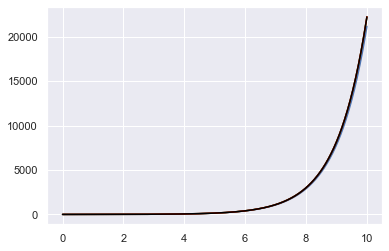

In [101]:
t0, x0 = 0, 1
tf = 10
dt = 0.01  

u1 = time.time()
t, x = solve_ivp_euler_explicit_variable_step(f,t0,x0,tf) # tracé à pas variable
u2 = time.time()
print(u2-u1)

v1 = time.time()
t_, x_ = solve_euler_explicit(f, dt, tf, x0 , t0) # tracé à pas fixe
v2 = time.time()
print(v2-v1)

plt.plot(t_, x_)
sol_ = [np.exp(temps) for temps in t_]
plt.plot(t_, sol_, color = 'green')

sol = [np.exp(t) for temps in t]
plt.plot(t, sol[1], color = 'red') # tracé théorique
plt.plot(t, x, color = 'black')
plt.show()

On observe la pertinence d'une méthode à pas variable face à une méthode à pas raide, en terme de précision : le pas s'adapte et n'a pas à être choisi au préalable pour assurer un bon suivi de la solution. Néanmoins, la méthode à pas fixe marche bien ici ; l'algorithme à pas variable n'a pas l'air plus rapide dans ce cas là, il faudrait l'essayer sur des équadiffs plus complexes.